# ERCOT - Ancillary Price Adders EDA (post 2025 Dec)

**Data source:** `post_202512_price_adders_hourly_binary.csv` and `rtm_lzhb_spp_20251205_20260516.parquet`

**Output source:** `rtm_price_ancillary_price_adder.csv`

- Schemas: `RTRDPA`, `RTRDPRU`, `RTRDPRD`, `RTRDPRRS`, `RTRDPECRS`, `RTRDPNS`
- Time range: 20251205 to 20260516

In [101]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


# Paths
PROJECT_ROOT = Path('../..').resolve()
PRICE_ADDERS_BI = PROJECT_ROOT / '01_data' / '3_analysis' / 'price_adders_analysis' / 'post_202512' / 'post_202512_price_adders_hourly_binary.csv'
PRICE_SPIKE = PROJECT_ROOT / '01_data' / '1.2_raw_api' / 'rtm_lzhb_spp_20251205_20260516.parquet'
OUT_DIR = PROJECT_ROOT / '01_data' / '3_analysis' / 'price_adders_analysis' / 'post_202512'
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [102]:
# import datasets

df_price_adders = pd.read_csv(PRICE_ADDERS_BI)
df_price_spike = pd.read_parquet(PRICE_SPIKE)

In [103]:
df_price_spike

,timestamp,delivery_date,delivery_hour,repeated_hour_flag,settlement_point,price
0,2025-12-05 00:00:00,2025-12-05,1,False,HB_BUSAVG,34.62
1,2025-12-05 00:00:00,2025-12-05,1,False,HB_HOUSTON,34.04
2,2025-12-05 00:00:00,2025-12-05,1,False,HB_HUBAVG,38.59
3,2025-12-05 00:00:00,2025-12-05,1,False,HB_NORTH,29.83
4,2025-12-05 00:00:00,2025-12-05,1,False,HB_PAN,-2.38
...,...,...,...,...,...,...
58660,2026-05-16 23:00:00,2026-05-16,24,False,LZ_LCRA,22.12
58661,2026-05-16 23:00:00,2026-05-16,24,False,LZ_NORTH,25.01
58662,2026-05-16 23:00:00,2026-05-16,24,False,LZ_RAYBN,25.09
58663,2026-05-16 23:00:00,2026-05-16,24,False,LZ_SOUTH,22.04


In [104]:
# RTM price is the average of all LZ and HB in ercot
df_price_spike['date_time'] = pd.to_datetime(df_price_spike['delivery_date']) + pd.to_timedelta(df_price_spike['delivery_hour'], unit='h')
df_price_spike = df_price_spike.groupby('date_time')['price'].mean().reset_index()
df_price_spike.to_csv(OUT_DIR / 'rtm_price_mean_20251205_20260516.csv', index=False)
df_price_spike

,date_time,price
0,2025-12-05 01:00:00,36.160000
1,2025-12-05 02:00:00,33.458667
2,2025-12-05 03:00:00,35.093333
3,2025-12-05 04:00:00,29.942667
4,2025-12-05 05:00:00,27.133333
...,...,...
3906,2026-05-16 20:00:00,18.740667
3907,2026-05-16 21:00:00,22.549333
3908,2026-05-16 22:00:00,22.714000
3909,2026-05-16 23:00:00,20.006000


In [76]:
# if any adder is active
cols = df_price_adders.columns.difference(['date'])
df_price_adders['if_adder'] = df_price_adders[cols].any(axis=1).astype(int)
df_price_adders

,date,RTRDPA,RTRDPRU,RTRDPRD,RTRDPRRS,RTRDPECRS,RTRDPNS,if_adder
0,2025-12-05 00:00:00,0,1,1,1,1,1,1
1,2025-12-05 01:00:00,0,1,1,1,1,1,1
2,2025-12-05 02:00:00,0,1,1,1,1,1,1
3,2025-12-05 03:00:00,0,1,1,0,0,1,1
4,2025-12-05 04:00:00,0,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...
3906,2026-05-16 19:00:00,0,1,1,1,1,1,1
3907,2026-05-16 20:00:00,0,1,1,1,1,1,1
3908,2026-05-16 21:00:00,0,1,1,1,1,1,1
3909,2026-05-16 22:00:00,0,1,1,1,1,1,1


In [77]:
# spike_hours uses hour-ending convention (01:00 = midnight–1am interval)
# price_adders uses hour-starting convention (00:00 = midnight–1am interval)
# shift spike timestamps back 1 hour to align before merging
df_price_spike['date_time'] = pd.to_datetime(df_price_spike['date_time']) - pd.Timedelta(hours=1)
df_price_adders['date'] = pd.to_datetime(df_price_adders['date'])
print(df_price_adders['date'].dtype)
print(df_price_spike['date_time'].dtype)

print(f'date: {df_price_adders["date"].min()} to {df_price_adders["date"].max()}')
print(f'date_time: {df_price_spike["date_time"].min()} to {df_price_spike["date_time"].max()}')

datetime64[us]
datetime64[us]
date: 2025-12-05 00:00:00 to 2026-05-16 23:00:00
date_time: 2025-12-04 23:00:00 to 2026-05-16 22:00:00


In [78]:
# merge two frames
df = pd.merge(df_price_adders, df_price_spike, left_on='date', right_on='date_time', how='right')
df_match = df.drop(['date_time'], axis=1)
df_match.to_csv(OUT_DIR / 'price_adders_activation_analysis_20251205_20260516.csv', index=False)
df_match

,date,RTRDPA,RTRDPRU,RTRDPRD,RTRDPRRS,RTRDPECRS,RTRDPNS,if_adder,price
0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.160000
1,2025-12-05 00:00:00,0.0,1.0,1.0,1.0,1.0,1.0,1.0,33.458667
2,2025-12-05 01:00:00,0.0,1.0,1.0,1.0,1.0,1.0,1.0,35.093333
3,2025-12-05 02:00:00,0.0,1.0,1.0,1.0,1.0,1.0,1.0,29.942667
4,2025-12-05 03:00:00,0.0,1.0,1.0,0.0,0.0,1.0,1.0,27.133333
...,...,...,...,...,...,...,...,...,...
3906,2026-05-16 18:00:00,0.0,1.0,1.0,1.0,1.0,1.0,1.0,18.740667
3907,2026-05-16 19:00:00,0.0,1.0,1.0,1.0,1.0,1.0,1.0,22.549333
3908,2026-05-16 20:00:00,0.0,1.0,1.0,1.0,1.0,1.0,1.0,22.714000
3909,2026-05-16 21:00:00,0.0,1.0,1.0,1.0,1.0,1.0,1.0,20.006000


### plot activation % by price percentile bins

In [105]:
##### change these parameters #####

# for number of bins (e.g., 20 for 5% quantiles, 100 for 1% quantiles)
bin_num = 100

# OPTIONAL: for how many bins to display in the plot (e.g., 10 for last 10 bins, 20 for last 20 bins)
last_bins = 10

###################################

In [106]:
# bin by percentile
df_bins = df_match.copy()
df_bins['price_quantile_bin'] = pd.qcut(df_bins['price'], q=bin_num, precision=3)
df_bins.head()

,date,RTRDPA,RTRDPRU,RTRDPRD,RTRDPRRS,RTRDPECRS,RTRDPNS,if_adder,price,price_quantile_bin
0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.160000,"(36.063, 37.009]"
1,2025-12-05 00:00:00,0.0,1.0,1.0,1.0,1.0,1.0,1.0,33.458667,"(32.902, 33.475]"
2,2025-12-05 01:00:00,0.0,1.0,1.0,1.0,1.0,1.0,1.0,35.093333,"(34.204, 35.179]"
3,2025-12-05 02:00:00,0.0,1.0,1.0,1.0,1.0,1.0,1.0,29.942667,"(29.444, 30.084]"
4,2025-12-05 03:00:00,0.0,1.0,1.0,0.0,0.0,1.0,1.0,27.133333,"(26.802, 27.17]"


In [107]:
# create activation rate table
adder_columns = ['RTRDPA', 'RTRDPRU', 'RTRDPRD', 'RTRDPRRS', 'RTRDPECRS', 'RTRDPNS']
activation_rate_table = df_bins.groupby('price_quantile_bin')[adder_columns + ['if_adder']].mean().reset_index()
activation_rate_table

,price_quantile_bin,RTRDPA,RTRDPRU,RTRDPRD,RTRDPRRS,RTRDPECRS,RTRDPNS,if_adder
0,"(-30.560000000000002, -5.453]",0.175000,1.000000,1.000000,0.800000,0.875000,1.0,1.0
1,"(-5.453, -2.211]",0.051282,0.974359,0.974359,0.897436,0.923077,1.0,1.0
2,"(-2.211, -1.158]",0.153846,0.897436,1.000000,0.871795,0.897436,1.0,1.0
3,"(-1.158, -0.132]",0.128205,0.897436,0.974359,0.871795,0.897436,1.0,1.0
4,"(-0.132, 0.441]",0.230769,0.974359,1.000000,0.897436,0.897436,1.0,1.0
...,...,...,...,...,...,...,...,...
95,"(75.64, 89.477]",0.333333,1.000000,0.923077,0.948718,0.974359,1.0,1.0
96,"(89.477, 116.793]",0.461538,1.000000,0.923077,0.923077,0.923077,1.0,1.0
97,"(116.793, 150.912]",0.538462,1.000000,0.974359,0.923077,0.923077,1.0,1.0
98,"(150.912, 266.151]",0.538462,1.000000,0.794872,0.948718,0.974359,1.0,1.0


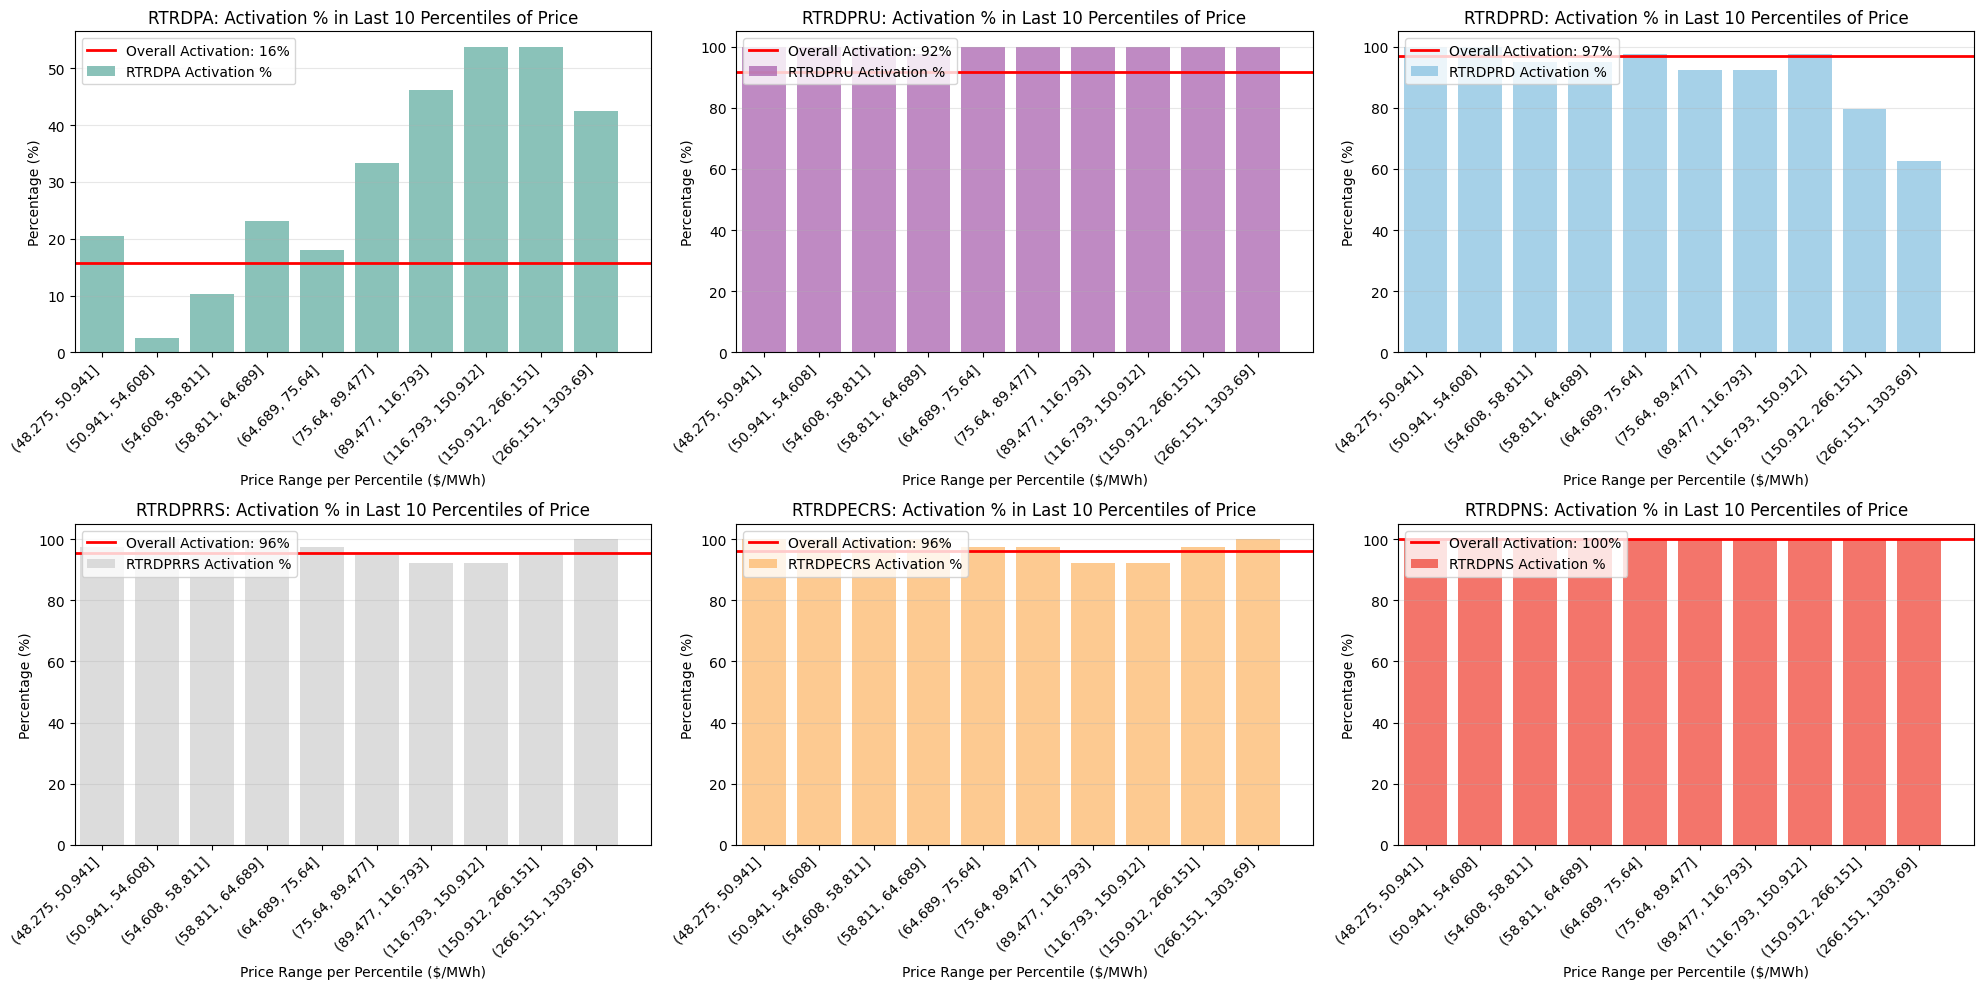

In [108]:
colors = ['#59a89c', "#a559aa9f", "#80bedf", '#cecece', '#fdb462', '#ef3b2c']

# Calculate baseline (% of True values in each column)
baseline = [df_bins[col].sum() / len(df_bins) * 100 for col in adder_columns]

# Create separate subplots for each adder type
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
positions = activation_rate_table['price_quantile_bin'].astype(str)

for i, col in enumerate(adder_columns):
    ax_i = axes[i // 3, i % 3]
    
    # Plot adder activation percentage
    ax_i.bar(positions, activation_rate_table[col] * 100, color=colors[i], alpha=0.7, label=f'{col} Activation %')
    
    # Add baseline line (overall spike percentage)
    ax_i.axhline(y=baseline[i], color='red', linestyle='-', linewidth=2, label=f'Overall Activation: {baseline[i]:.0f}%')
    
    ax_i.set_xlabel('Price Range per Percentile ($/MWh)')
    ax_i.set_ylabel('Percentage (%)')
    ax_i.set_title(f'{col}: Activation % in Last {last_bins} Percentiles of Price')
    ax_i.set_xticks(positions)
    ax_i.set_xticklabels(positions, rotation=45, ha='right')
    ax_i.set_xlim(len(positions)-last_bins-0.5, len(positions))
    ax_i.legend(loc='upper left')
    ax_i.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/price_adder_percentiles_last_{last_bins}_{100/bin_num}.png', dpi=300, bbox_inches='tight')
plt.show()